In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

data = pd.read_csv('Mall_Customers.csv')
df = pd.DataFrame(data)

X = df[["Age", "Annual Income (k$)", "Spending Score (1-100)"]]


# ELBOW PLOT

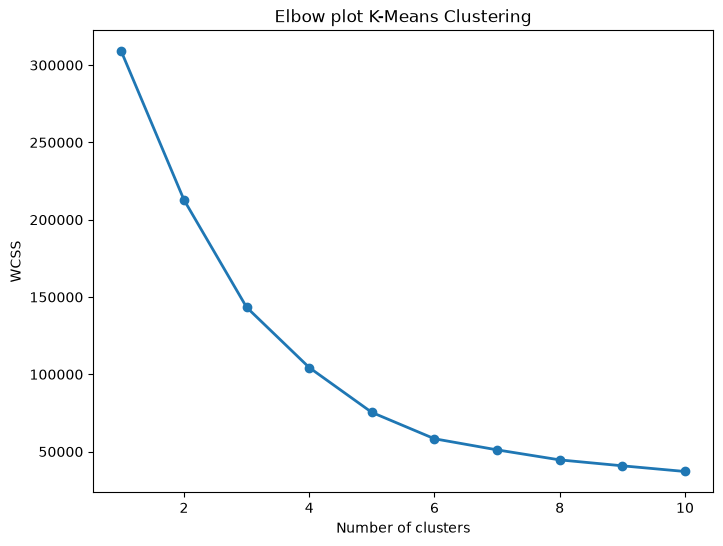

In [76]:
wcss = []

for k in range(1,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=15
    )

    model.fit(X)

    wcss.append(model.inertia_)

plt.figure(figsize=(8, 6))

plt.plot(
    range(1,11),
    wcss,
    marker="o",
    linewidth=2
)
plt.title("Elbow plot K-Means Clustering")
plt.xlabel("Number of clusters")
plt.ylabel("WCSS")
plt.show()

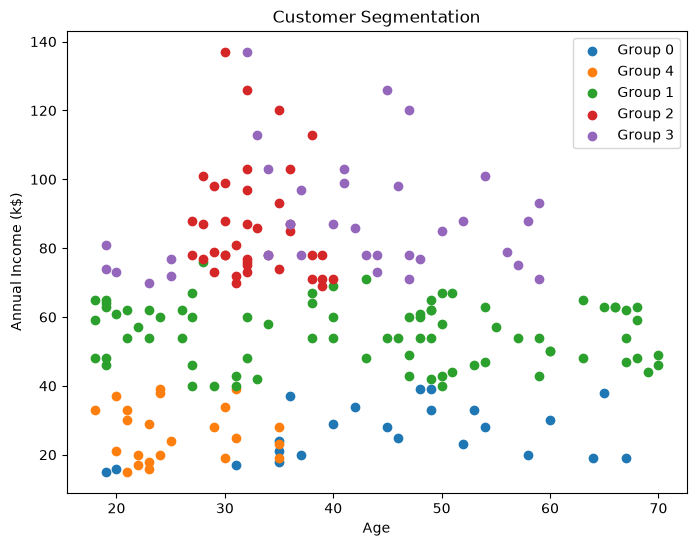

In [77]:
model = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=15
)

df['group'] = model.fit_predict(X)

plt.figure(figsize=(8, 6))

for group in df['group'].unique():

    group_data = df[df['group'] == group]

    plt.scatter(
        group_data['Age'],
        group_data['Annual Income (k$)'],
        label=f'Group {group}'
    )

plt.title("Customer Segmentation")
plt.xlabel("Age")
plt.ylabel("Annual Income (k$)")
plt.legend()

plt.show()

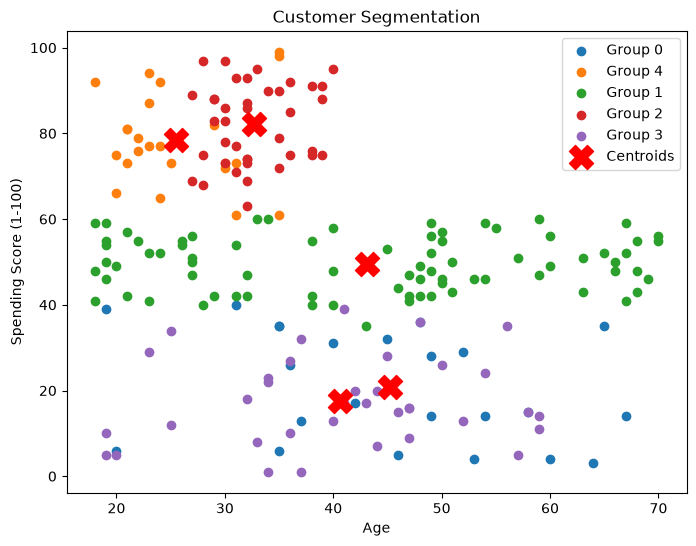

In [78]:
plt.figure(figsize=(8,6))

for group in df['group'].unique():
    group_data = df[df['group'] == group]

    plt.scatter(
        group_data['Age'],
        group_data['Spending Score (1-100)'],
        label=f'Group {group}'
    )

centroids = model.cluster_centers_

plt.scatter(
    centroids[:, 0],
    centroids[:, 2],
    c='red',
    marker='X',
    s=300,
    label='Centroids'
)

plt.title("Customer Segmentation")
plt.xlabel("Age")
plt.ylabel("Spending Score (1-100)")
plt.legend()
plt.show()

In [79]:
print(df)

     CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1    Male   19                  15                      39   
1             2    Male   21                  15                      81   
2             3  Female   20                  16                       6   
3             4  Female   23                  16                      77   
4             5  Female   31                  17                      40   
..          ...     ...  ...                 ...                     ...   
195         196  Female   35                 120                      79   
196         197  Female   45                 126                      28   
197         198    Male   32                 126                      74   
198         199    Male   32                 137                      18   
199         200    Male   30                 137                      83   

     group  
0        0  
1        4  
2        0  
3        4  
4        0  
..     ..

In [81]:
# User Input

age = int(input("Enter Age: "))
income = float(input("Enter Annual Income (k$): "))
spending = float(input("Enter Spending Score (1-100): "))

new_customer = [[age, income, spending]]
predicition= model.predict(new_customer)

print(f"\nCustomer belongs to Group {predicition[0]}")


Customer belongs to Group 2


C:\Users\ROG STRIX\Desktop\kmeans\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but KMeans was fitted with feature names
  warnings.warn(
